In [ ]:
#| default_exp models.mv_pesh

In [ ]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Union, Any
import numpy as np
import pandas as pd
import copy
import warnings
warnings.filterwarnings("ignore")

class mv_pesh:
    """
    Multivariate Probabilistic Forecaster combining per-series best models
    with cross-series residual error covariance matrix estimation.
    """
    def __init__(
        self,
        models: Dict[str, Any],
        covariance_mode: str = "cross_series",
        shrinkage: float = 1e-4
    ) -> None:
        """
        Parameters
        ----------
        models : dict
            Dictionary mapping series name -> model instance.
            Each model instance is tailored/fitted for that specific target series.
        covariance_mode : str, default "cross_series"
            Mode for residual error covariance matrix estimation.
            Options: "cross_series" (estimates N x N covariance matrix across series).
        shrinkage : float, default 1e-4
            Regularization added to the diagonal of the covariance matrix
            to ensure positive definiteness for Cholesky decomposition.
        """
        self.models = models
        self.covariance_mode = covariance_mode
        self.shrinkage = shrinkage
        self.target_cols = list(models.keys())
        self.n_series = len(self.target_cols)
        self.is_fitted = False

    def copy(self):
        return copy.deepcopy(self)

    def get_name(self) -> str:
        return "mv_pesh"

    def fit(self, df: pd.DataFrame) -> mv_pesh:
        """
        Fit each series model on its respective series data and compute
        the cross-series residual error covariance matrix.

        Parameters
        ----------
        df : pd.DataFrame
            DataFrame containing target series and optional exogenous features.
        """
        self.residuals_ = {}
        exog_cols = [c for c in df.columns if c not in self.target_cols]
        self.exog_cols_ = exog_cols

        for col, model in self.models.items():
            model_df = df[[col] + exog_cols] if exog_cols else df[[col]]
            model.fit(model_df)
            if hasattr(model, "predict_in_sample"):
                model.predict_in_sample()
                if hasattr(model, "in_samp_resids") and model.in_samp_resids is not None:
                    res = model.in_samp_resids
                    if isinstance(res, (pd.Series, pd.DataFrame)):
                        res = res.values.flatten()
                    self.residuals_[col] = np.array(res, dtype=float)

        if len(self.residuals_) == self.n_series:
            min_len = min(len(r) for r in self.residuals_.values())
            # res_matrix = np.column_stack([self.residuals_[col][-min_len:] for col in self.target_cols])
            res_matrix = np.column_stack([self.residuals_[col][-150:] for col in self.target_cols])
            self.res_matrix_ = res_matrix
            cov = np.cov(res_matrix, rowvar=False)
            if self.n_series == 1:
                cov = np.array([[cov]])
            self.cov_matrix_ = cov + np.eye(self.n_series) * self.shrinkage
        else:
            self.cov_matrix_ = np.eye(self.n_series) * self.shrinkage
            self.res_matrix_ = np.zeros((10, self.n_series))

        self.is_fitted = True
        return self

    def forecast(
        self,
        H: int,
        exog: Optional[Union[pd.DataFrame, Dict[str, pd.DataFrame]]] = None,
        use_scenarios: bool = False,
        n_samples: int = 1000,
        method: str = "gaussian",
        random_state: int = 42
    ) -> pd.DataFrame:
        """
        Generate point forecasts for all series.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame | dict | None, default None
            Optional exogenous features for forecast horizon.
        use_scenarios : bool, default False
            If True, point forecasts are calculated as the expected mean across
            n_samples generated multivariate scenarios (accounting for error covariance).
        n_samples : int, default 1000
            Number of scenarios to draw when use_scenarios=True.
        method : str, default "gaussian"
            Sampling method when use_scenarios=True ("gaussian", "cholesky", or "bootstrap").
        random_state : int, default 42
            Random seed when use_scenarios=True.

        Returns
        -------
        pd.DataFrame
            DataFrame of shape (H, N) with columns as target series names.
        """
        if not self.is_fitted:
            raise RuntimeError("Model must be fitted before calling forecast.")

        if use_scenarios:
            scenarios = self.sample(
                H=H,
                n_samples=n_samples,
                exog=exog,
                method=method,
                random_state=random_state
            )  # Shape (n_samples, N, H)
            mean_scenarios = scenarios.mean(axis=0).T  # Shape (H, N)
            return pd.DataFrame(mean_scenarios, columns=self.target_cols)

        point_forecasts = {}
        for col, model in self.models.items():
            if isinstance(exog, dict):
                model_exog = exog.get(col)
            elif isinstance(exog, pd.DataFrame) and self.exog_cols_:
                model_exog = exog[self.exog_cols_]
            else:
                model_exog = None

            if model_exog is not None and len(model_exog) > 0:
                fc = model.forecast(H=H, exog=model_exog)
            else:
                fc = model.forecast(H=H)

            if isinstance(fc, pd.DataFrame):
                if col in fc.columns:
                    fc = fc[col].values
                else:
                    fc = fc.iloc[:, 0].values
            elif isinstance(fc, pd.Series):
                fc = fc.values
            elif isinstance(fc, np.ndarray):
                fc = fc.flatten()
            point_forecasts[col] = fc

        return pd.DataFrame(point_forecasts)

    def sample(
        self,
        H: int,
        n_samples: int = 1000,
        exog: Optional[Union[pd.DataFrame, Dict[str, pd.DataFrame]]] = None,
        method: str = "gaussian",
        random_state: int = 42
    ) -> np.ndarray:
        """
        Sample scenario matrices from the multivariate probabilistic forecast distribution.

        Parameters
        ----------
        H : int
            Forecast horizon.
        n_samples : int, default 1000
            Number of scenario paths to draw.
        exog : pd.DataFrame | dict | None, default None
            Exogenous data for forecast period.
        method : str, default "gaussian"
            Sampling method:
            - "gaussian" / "multivariate": draws from numpy's `rng.multivariate_normal`.
            - "cholesky": draws standard normal noise transformed by Cholesky factor (L @ Z).
            - "bootstrap": resamples historical residual vectors non-parametrically.
        random_state : int, default 42
            Random seed.

        Returns
        -------
        np.ndarray
            Array of shape (n_samples, N, H) containing sampled forecast scenarios.
            Axis 0: sample index (0..n_samples-1)
            Axis 1: series index (0..N-1)
            Axis 2: forecast horizon step (0..H-1)
        """
        mean_df = self.forecast(H=H, exog=exog, use_scenarios=False)
        mean_matrix = mean_df[self.target_cols].values.T  # Shape (N, H)

        rng = np.random.default_rng(seed=random_state)
        N = self.n_series

        if method in ["gaussian", "multivariate", "multivariate_normal"]:
            noise = rng.multivariate_normal(
                mean=np.zeros(N),
                cov=self.cov_matrix_,
                size=(n_samples, H)
            )  # Shape (n_samples, H, N)
            noise = np.transpose(noise, (0, 2, 1))  # Shape (n_samples, N, H)

        elif method == "cholesky":
            L = np.linalg.cholesky(self.cov_matrix_)  # Shape (N, N)
            z = rng.normal(size=(n_samples, N, H))     # Shape (n_samples, N, H)
            noise = np.matmul(L, z)                    # Shape (n_samples, N, H)

        elif method == "bootstrap":
            res = self.res_matrix_
            T_res = res.shape[0]
            idx = rng.choice(T_res, size=(n_samples, H), replace=True)
            sampled_res = res[idx]
            noise = np.transpose(sampled_res, (0, 2, 1))  # Shape (n_samples, N, H)

        else:
            raise ValueError("Method must be one of ['gaussian', 'multivariate', 'cholesky', 'bootstrap'].")

        scenarios = mean_matrix[np.newaxis, :, :] + noise  # Shape (n_samples, N, H)
        return scenarios

    def predict_intervals(
        self,
        H: int,
        quantiles: List[float] = [0.1, 0.5, 0.9],
        n_samples: int = 1000,
        exog: Optional[Union[pd.DataFrame, Dict[str, pd.DataFrame]]] = None,
        method: str = "gaussian",
        random_state: int = 42
    ) -> Dict[str, pd.DataFrame]:
        """
        Generate prediction intervals per series based on sampled scenarios.

        Parameters
        ----------
        H : int
            Forecast horizon.
        quantiles : list of float, default [0.1, 0.5, 0.9]
            Quantile levels to evaluate.
        n_samples : int, default 1000
            Number of scenarios to draw for quantile estimation.
        exog : pd.DataFrame | dict | None, default None
            Exogenous data.
        method : str, default "gaussian"
            Sampling method ("gaussian", "cholesky", or "bootstrap").
        random_state : int, default 42
            Random seed.

        Returns
        -------
        dict of pd.DataFrame
            Key: series name. Value: DataFrame of shape (H, len(quantiles)+1)
            containing point forecast and requested quantiles.
        """
        scenarios = self.sample(H=H, n_samples=n_samples, exog=exog, method=method, random_state=random_state)
        point_fc = pd.DataFrame(scenarios.mean(axis=0).T, columns=self.target_cols)

        results = {}
        for idx, col in enumerate(self.target_cols):
            series_paths = scenarios[:, idx, :]
            df_quant = pd.DataFrame({"point_forecast": point_fc[col].values})
            for q in sorted(quantiles):
                q_vals = np.percentile(series_paths, q * 100, axis=0)
                q_name = f"q_{int(q * 100)}"
                df_quant[q_name] = q_vals
            results[col] = df_quant

        return results


=== Point Forecast Metrics: Individual vs mv_pesh Scenario Mean ===
  Series  MAE (Ind)  MAE (mv_pesh Scenario Mean)  RMSE (Ind)  RMSE (mv_pesh Scenario Mean)
 realgdp   214.9162                     216.1834    294.6800                      295.4985
realcons   827.3312                     829.4644    829.8597                      831.8018
 realinv   361.9287                     362.7408    468.4522                      468.2867
 realdpi   247.5667                     247.4039    264.8992                      265.4712
   unemp     1.2034                       1.2034      1.8047                        1.8077


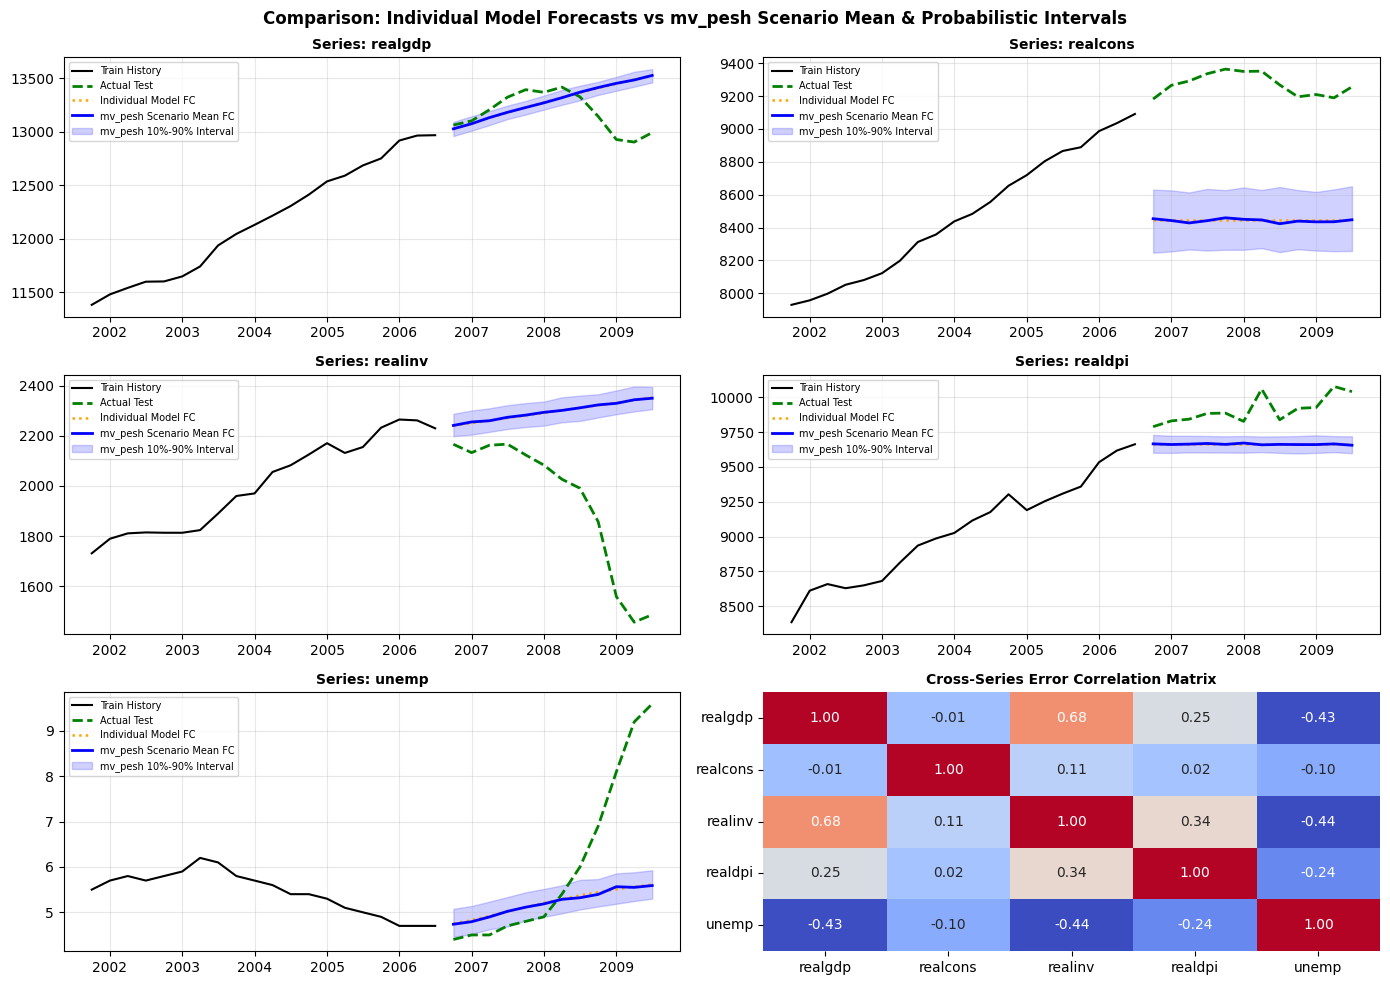

In [ ]:
#| hide
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from peshbeen.datasets import load_macrodata
from peshbeen.models import arima, ml_forecaster, ets, naive, glm, mv_pesh
from peshbeen.metrics import MAE, RMSE
from lightgbm import LGBMRegressor
import statsmodels.api as sm

# 1. Load multi-series macrodata
cols = ['realgdp', 'realcons', 'realinv', 'realdpi', 'unemp']
df = load_macrodata(columns=cols)

test_size = 12
train_df = df.iloc[:-test_size]
test_df = df.iloc[-test_size:]
H = test_size

# 2. Define best models per series
models = {
    'realgdp': arima(target_col='realgdp', order=(1, 1, 1)),
    'realcons': ml_forecaster(LGBMRegressor(verbosity=-1, random_state=42), target_col='realcons', lags=4),
    'realinv': ets(target_col='realinv', trend='add'),
    'realdpi': naive(target_col='realdpi'),
    'unemp': glm(family=sm.families.Gaussian(), target_col='unemp', lags=2)
}

# 3. Fit individual models independently
ind_point_forecasts = {}
for col, model in models.items():
    model.fit(train_df[[col]])
    fc = model.forecast(H=H)
    if isinstance(fc, pd.DataFrame):
        fc_vals = fc[col].values if col in fc.columns else fc.iloc[:, 0].values
    elif isinstance(fc, pd.Series):
        fc_vals = fc.values
    else:
        fc_vals = fc.flatten()
    ind_point_forecasts[col] = fc_vals

ind_fc_df = pd.DataFrame(ind_point_forecasts, index=test_df.index)

# 4. Fit joint multivariate model (mv_pesh)
mv_model = mv_pesh(models=models, shrinkage=1e-4)
mv_model.fit(train_df)

# Point forecasts for mv_pesh calculated as MEAN OF SCENARIOS (accounting for error covariance)
mv_fc_df = mv_model.forecast(H=H, use_scenarios=True, n_samples=100, method="cholesky", random_state=42)
mv_fc_df.index = test_df.index

scenarios_g = mv_model.sample(H=H, n_samples=500, method="gaussian", random_state=42)
scenarios_c = mv_model.sample(H=H, n_samples=500, method="cholesky", random_state=42)
scenarios_b = mv_model.sample(H=H, n_samples=500, method="bootstrap", random_state=42)
intervals = mv_model.predict_intervals(H=H, quantiles=[0.1, 0.9], n_samples=500, method="gaussian")

# 5. Print Comparison Table: Individual Models vs mv_pesh (Scenario Mean)
comp_data = []
for col in cols:
    y_t = test_df[col].values
    y_i = ind_fc_df[col].values
    y_m = mv_fc_df[col].values
    comp_data.append({
        'Series': col,
        'MAE (Ind)': round(MAE(y_t, y_i), 4),
        'MAE (mv_pesh Scenario Mean)': round(MAE(y_t, y_m), 4),
        'RMSE (Ind)': round(RMSE(y_t, y_i), 4),
        'RMSE (mv_pesh Scenario Mean)': round(RMSE(y_t, y_m), 4)
    })
print("=== Point Forecast Metrics: Individual vs mv_pesh Scenario Mean ===")
print(pd.DataFrame(comp_data).to_string(index=False))

# 6. Multi-Panel Visualization Plot
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle("Comparison: Individual Model Forecasts vs mv_pesh Scenario Mean & Probabilistic Intervals", fontsize=12, fontweight='bold')

for idx, col in enumerate(cols):
    ax = axes[idx // 2, idx % 2]
    ax.plot(train_df.index[-20:], train_df[col].iloc[-20:], label="Train History", color="black", lw=1.5)
    ax.plot(test_df.index, test_df[col], label="Actual Test", color="green", lw=2, linestyle="--")
    ax.plot(test_df.index, ind_fc_df[col], label="Individual Model FC", color="orange", lw=1.8, linestyle=":")
    ax.plot(test_df.index, mv_fc_df[col], label="mv_pesh Scenario Mean FC", color="blue", lw=2)
    q10 = intervals[col]['q_10'].values
    q90 = intervals[col]['q_90'].values
    ax.fill_between(test_df.index, q10, q90, color="blue", alpha=0.18, label="mv_pesh 10%-90% Interval")
    ax.set_title(f"Series: {col}", fontsize=10, fontweight='bold')
    ax.legend(loc="upper left", fontsize=7)
    ax.grid(True, alpha=0.3)

# 6th Subplot: Residual Error Correlation Heatmap
ax_corr = axes[2, 1]
cov_mat = mv_model.cov_matrix_
std_devs = np.sqrt(np.diag(cov_mat))
corr_mat = cov_mat / np.outer(std_devs, std_devs)
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=cols, yticklabels=cols, ax=ax_corr, cbar=False)
ax_corr.set_title("Cross-Series Error Correlation Matrix", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
